**Heart Disease Prediction Project**

This project predicts heart disease risk using the "framingham.csv.xls" dataset. Below, we perform data cleaning, exploratory data analysis, machine learning, and evaluation.


In [15]:
# Import libraries for data manipulation and analysis
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical operations
#Import libraries for EDA
from collections import Counter # For counting occurrences of elements in a dataset
import dtale # For interactive data exploration
import sweetviz as sv # For creating beautiful visualizations for data analysis
# Import libraries for data visualization
import matplotlib.pyplot as plt  # For creating plots and visualizations
import seaborn as sns            # For advanced data visualizations
# Import libraries for machine learning tasks
from sklearn.model_selection import train_test_split  # For splitting the dataset into train and test sets
from sklearn.impute import SimpleImputer              # For handling missing values
from sklearn.preprocessing import StandardScaler      # For scaling features
from sklearn.metrics import (accuracy_score,         # For calculating accuracy
                             confusion_matrix,       # For confusion matrix
                             classification_report,  # For classification metrics report
                             roc_curve,              # For ROC curve
                             auc,                    # For AUC calculation
                             ConfusionMatrixDisplay) # For visualizing confusion matrix
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.neighbors import KNeighborsClassifier   # K-Nearest Neighbors classifier
# Import libraries for deep learning tasks
import torch                         # Core PyTorch library
import torch.nn as nn                # Neural network modules
import torch.optim as optim          # Optimizers for training


In [16]:


# Load the dataset
data = pd.read_csv("framingham.csv.xls")
data.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [17]:
data.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


**Visualizing Interactive data exploration with EDA**

In [18]:
dtale.show(data)

**Visualizing creating beautiful visualizations for data analysis with EDA**

In [19]:
# Analyze the dataset
report = sv.analyze(data)

# Generate an HTML report and save it with the name 'heart-Disease.html'
report.show_html("heart-Disease.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report heart-Disease.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Step 1: Data Overview and Cleaning**

- Check dataset structure.
- Display column data types and null values.
- Remove missing values.
- Convert categorical and numerical columns appropriately.


In [20]:
# Display basic dataset information
print(data.info())
print(data.head())
print(data.tail())
print(f"Dataset Shape: {data.shape}")

# Check and handle missing values
print("\nMissing Values per Column:\n", data.isnull().sum())
data = data.dropna()
print(f"Shape after removing missing values: {data.shape}")

# Check the range of age
minAge = min(data.age)
maxAge = max(data.age)
meanAge = data.age.mean()
print(f"Min Age: {minAge}, Max Age: {maxAge}, Mean Age: {meanAge}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB
None
   male 

**Step 2: Exploratory Data Analysis**

1. Age Distribution
2. Chest Pain Type Analysis
3. Target Analysis
4. Thal Analysis
5. Histogram of Prediction Probabilities
6. Correlation Heatmap


2025-01-14 01:15:46,520 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/zm/p6knz7dd2lx_gxmh3mxmpc600000gn/T/ipykernel_79126/3093382719.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


2025-01-14 01:15:46,546 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Min Age: 32
Max Age: 70
Mean Age: 49.56


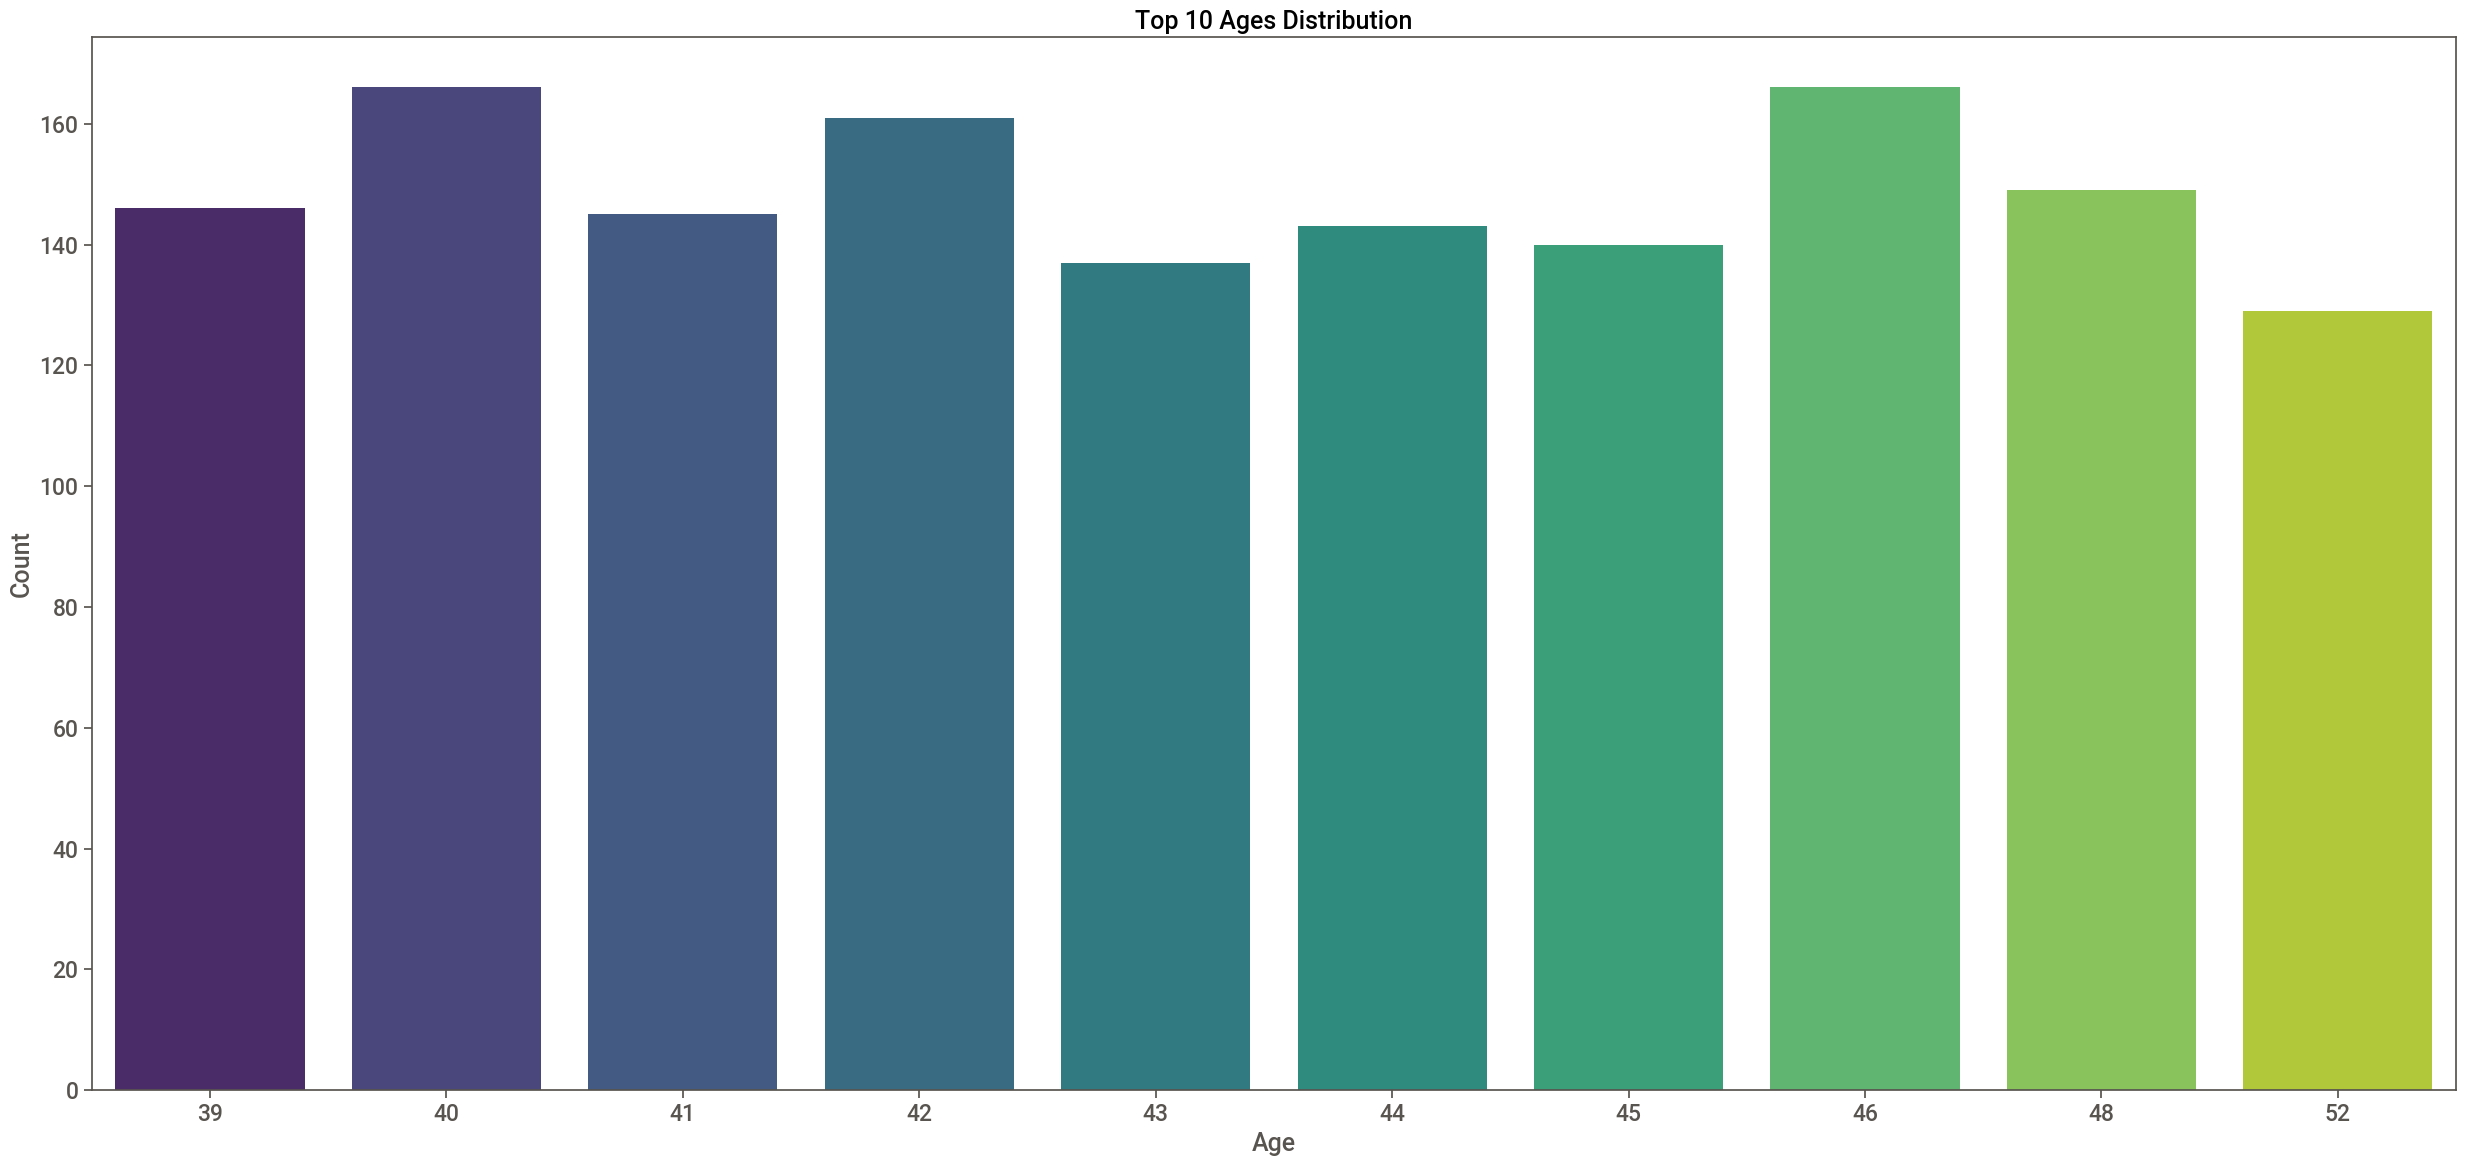

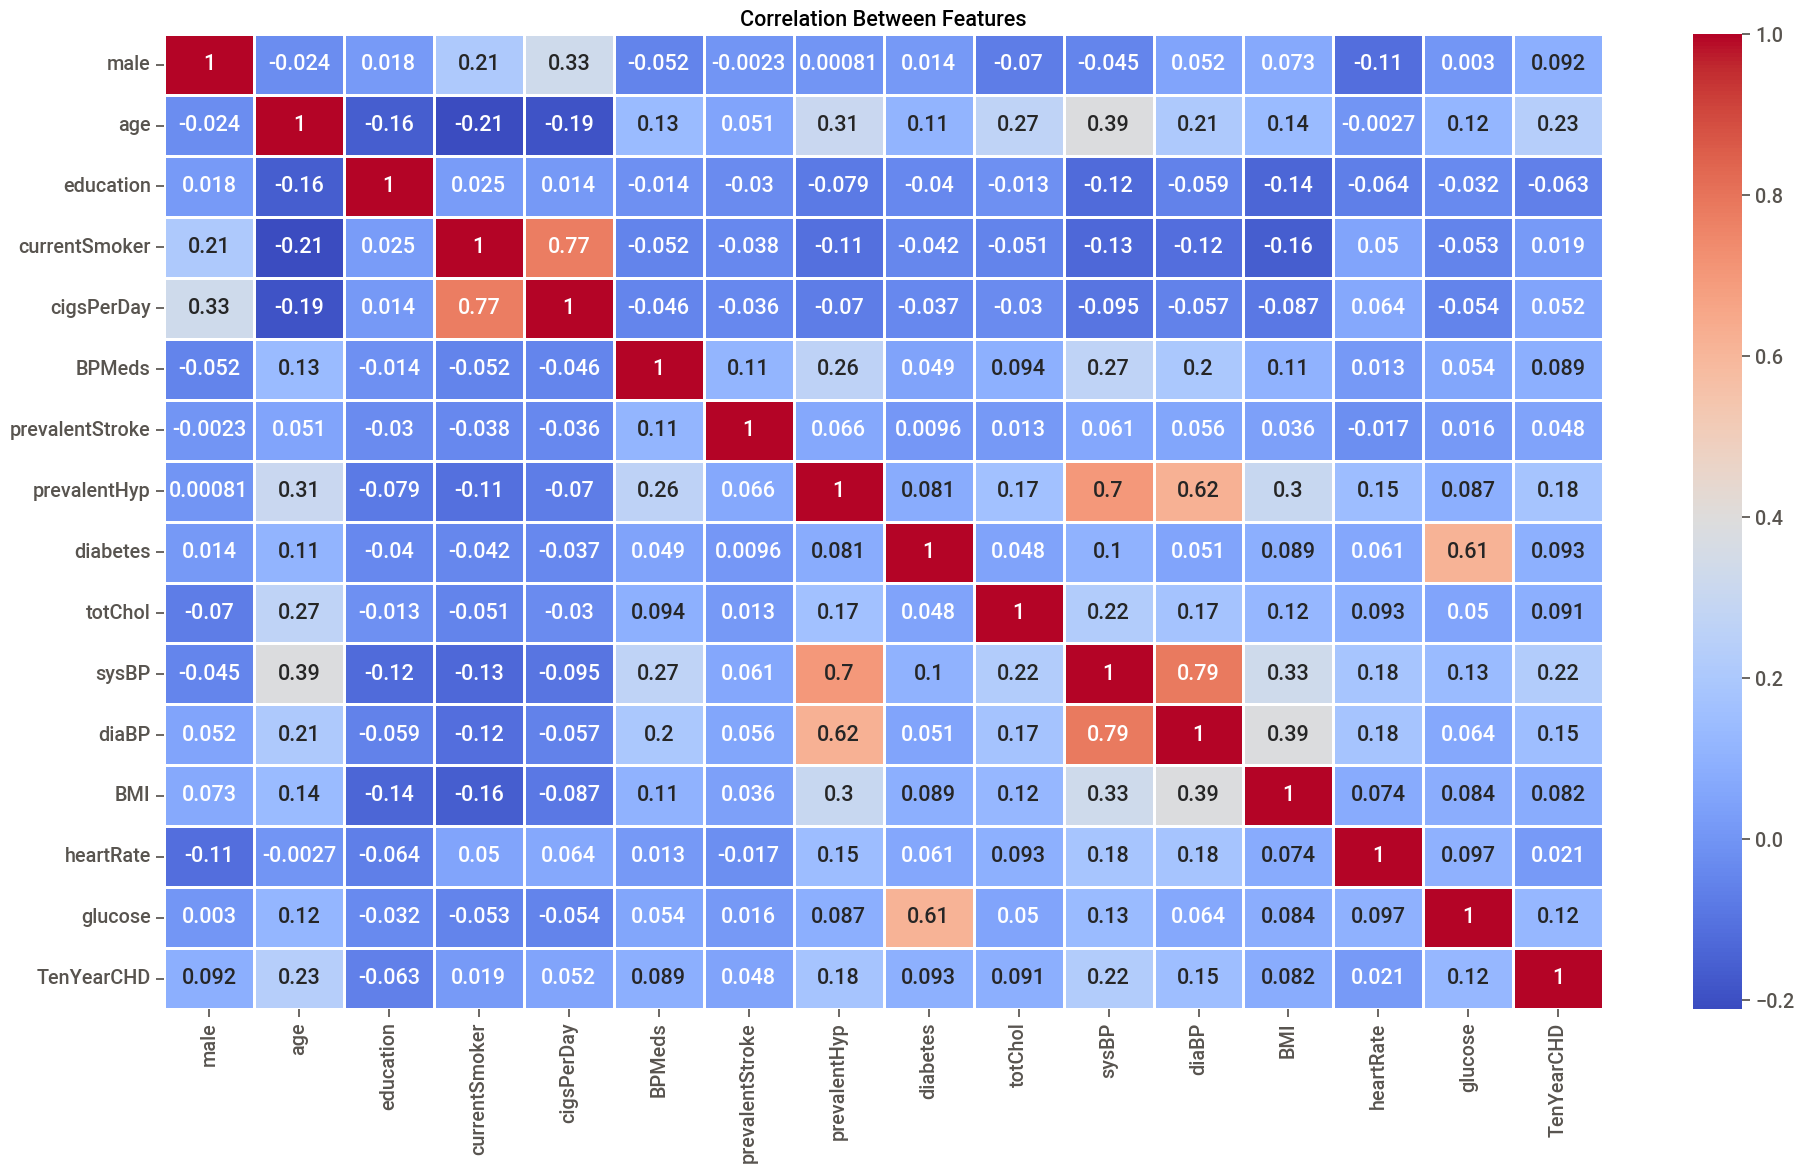

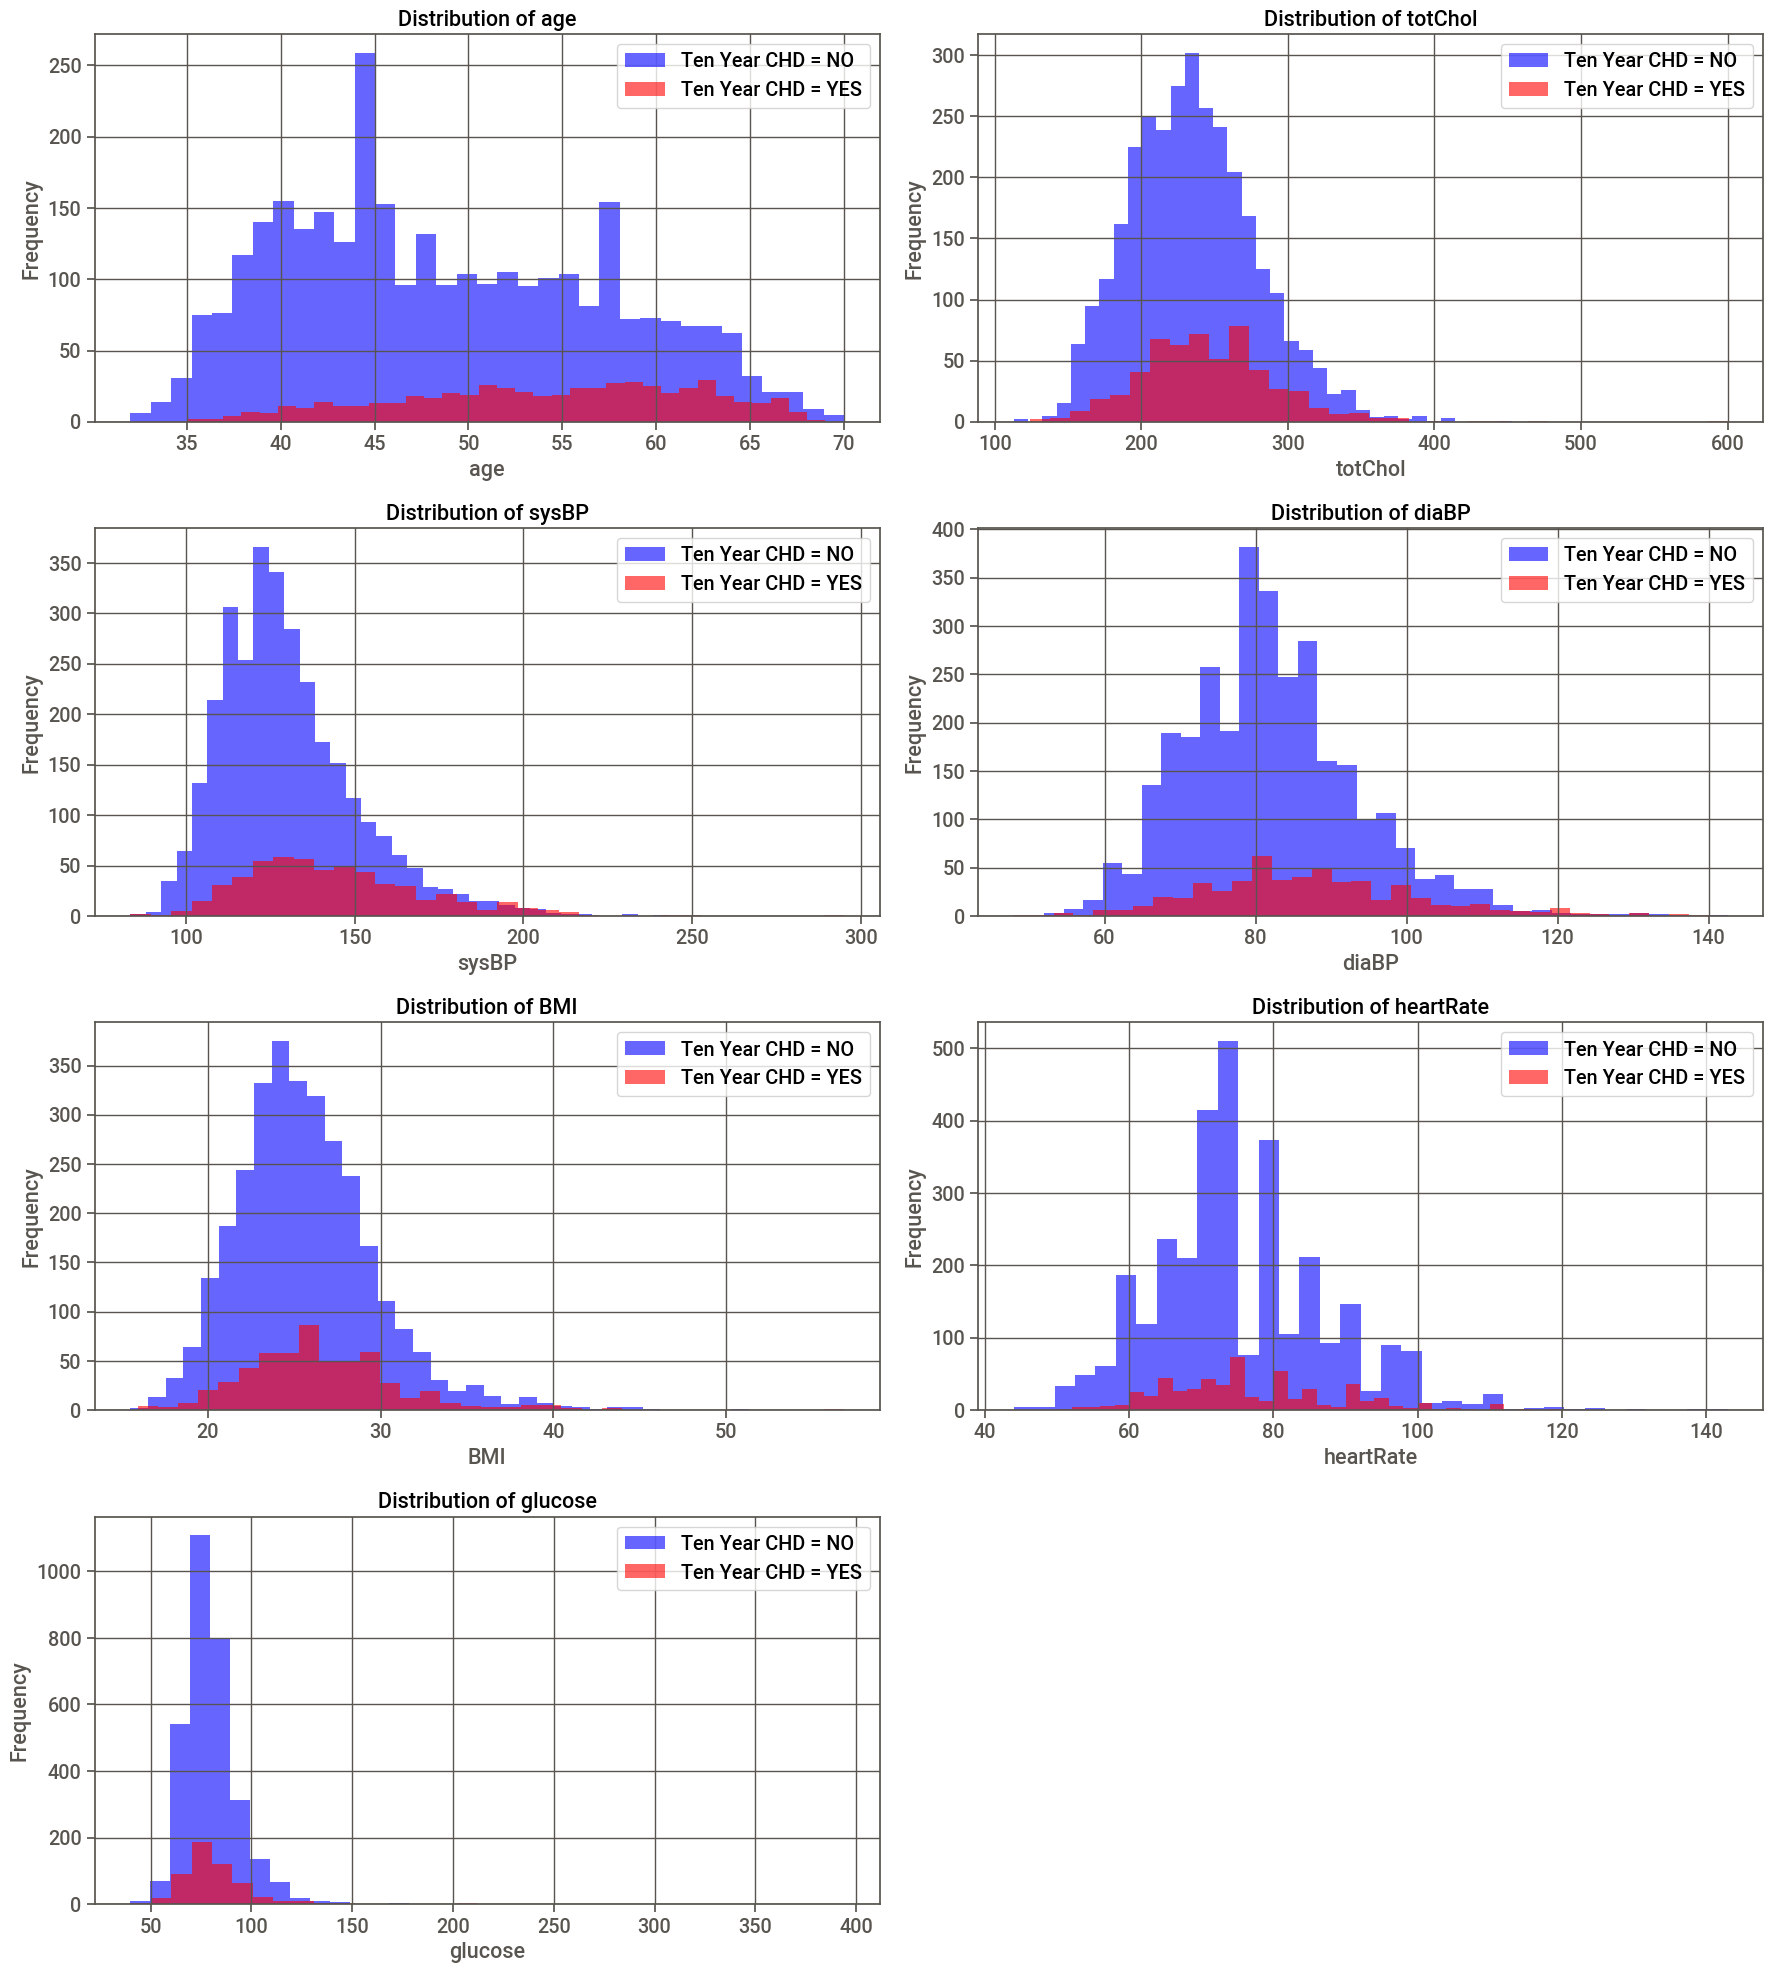

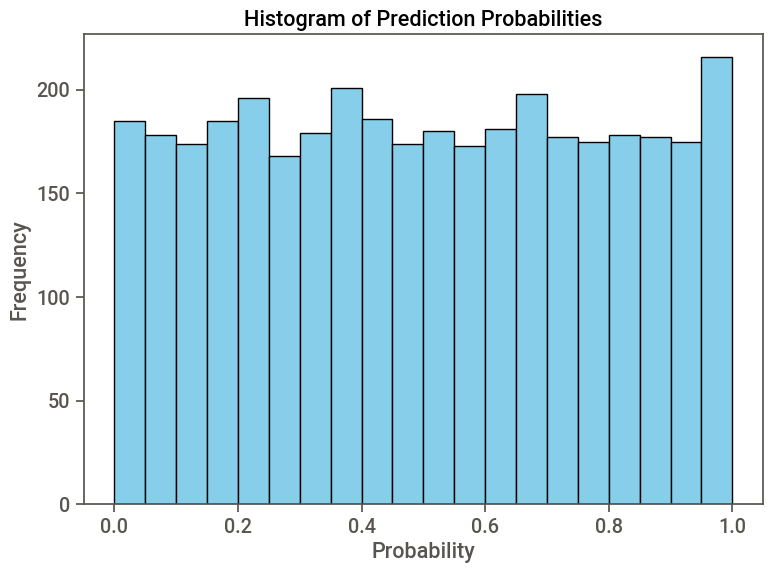

In [21]:
# Analyze the range of ages in the dataset
minAge = min(data.age)
maxAge = max(data.age)
meanAge = data.age.mean()
print(f"Min Age: {minAge}")
print(f"Max Age: {maxAge}")
print(f"Mean Age: {meanAge:.2f}")

# Bar plot for top 10 ages and their counts
plt.figure(figsize=(25, 12))
sns.set_context('notebook', font_scale=1.5)
sns.barplot(x=data.age.value_counts()[:10].index, y=data.age.value_counts()[:10].values, palette="viridis")
plt.title("Top 10 Ages Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Analyze correlations between features
plt.figure(figsize=(20, 12))
sns.set_context('notebook', font_scale=1.3)
sns.heatmap(data.corr(), annot=True, linewidths=2, cmap="coolwarm")
plt.title("Correlation Between Features")
plt.tight_layout()
plt.show()

# Continuous features grouped by the presence or absence of heart disease
plt.figure(figsize=(18, 20))
continous_val = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
rows = 4  
cols = 2 

for i, column in enumerate(continous_val, 1):
    plt.subplot(rows, cols, i)
    data[data["TenYearCHD"] == 0][column].hist(bins=35, color='blue', label='Ten Year CHD = NO', alpha=0.6)
    data[data["TenYearCHD"] == 1][column].hist(bins=35, color='red', label='Ten Year CHD = YES', alpha=0.6)
    plt.legend()
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

# Example placeholder probabilities for visualization
# Replace with actual prediction probabilities
dummy_probs = np.random.rand(len(data)) 
plt.figure(figsize=(8, 6))
plt.hist(dummy_probs, bins=20, color="skyblue", edgecolor="black")
plt.title("Histogram of Prediction Probabilities")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**Step 3: Histogram of Continuous Variables**

Histograms for each continuous feature, split by target values (Heart Disease = YES/NO).


2025-01-14 01:15:53,141 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/zm/p6knz7dd2lx_gxmh3mxmpc600000gn/T/ipykernel_79126/4247298591.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


2025-01-14 01:15:53,157 - INFO     - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   
5     0   43        2.0              0         0.0     0.0                0   
6

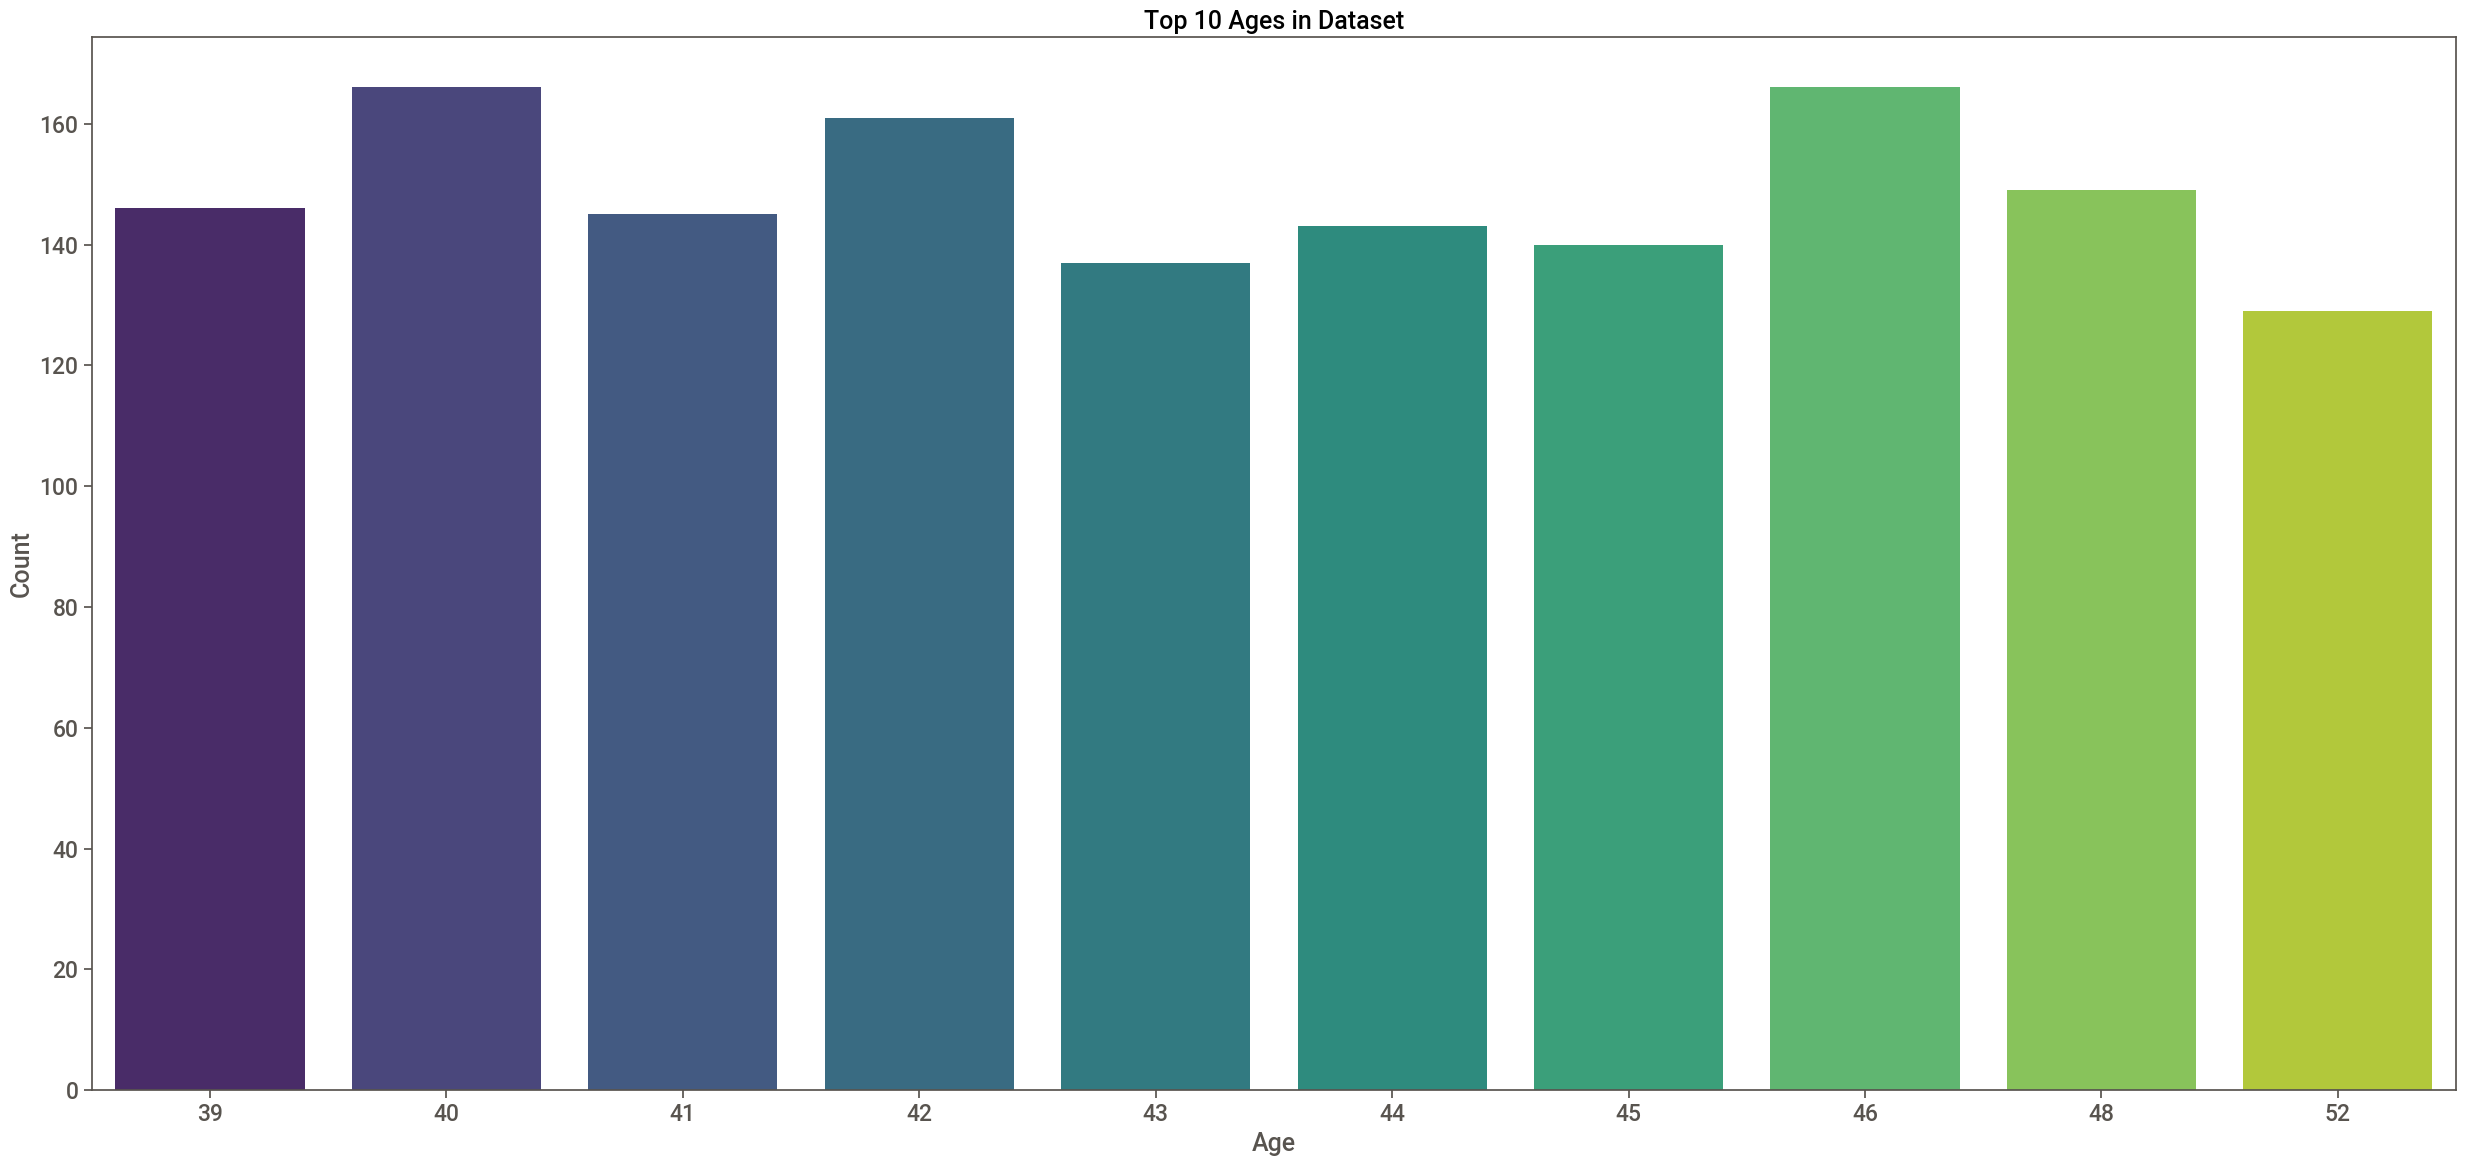

In [22]:
# Check data types
print(data.dtypes)

# Display the first 10 rows of the dataset
print(data.head(10))

# Predict the number of males in the dataset
num_males = data['male'].sum()
print("Number of males in the dataset:", num_males)

# Check for missing values
missing_values = data.isnull().sum()
print("\nMissing Values:\n", missing_values)

# Drop rows with missing values and save as 'subset'
subset = data.dropna()

# Check the range of age in the dataset
minAge = min(data['age'])
maxAge = max(data['age'])
meanAge = data['age'].mean()
print(f"Min Age: {minAge}, Max Age: {maxAge}, Mean Age: {meanAge:.2f}")

# Age Analysis: Checking the 10 most frequent ages
plt.figure(figsize=(25, 12))
sns.set_context('notebook', font_scale=1.5)
sns.barplot(x=data['age'].value_counts()[:10].index, 
            y=data['age'].value_counts()[:10].values, 
            palette="viridis")
plt.title('Top 10 Ages in Dataset')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Step 4: Data Preprocessing**

- Split data into training (60%) and testing (40%) sets.
- Scale feature values.


In [23]:
# Prepare data
X = data.drop(columns=["TenYearCHD"])  # Features
y = data["TenYearCHD"]  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Step 5: Machine Learning Models**

1. Logistic Regression
2. K-Nearest Neighbors (KNN)


In [24]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Evaluate Logistic Regression
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate KNN
print("K-Nearest Neighbors:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))


Logistic Regression:
Accuracy: 0.849624060150376
Confusion Matrix:
 [[1224   10]
 [ 210   19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.92      1234
           1       0.66      0.08      0.15       229

    accuracy                           0.85      1463
   macro avg       0.75      0.54      0.53      1463
weighted avg       0.82      0.85      0.80      1463

K-Nearest Neighbors:
Accuracy: 0.83526999316473
Confusion Matrix:
 [[1198   36]
 [ 205   24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91      1234
           1       0.40      0.10      0.17       229

    accuracy                           0.84      1463
   macro avg       0.63      0.54      0.54      1463
weighted avg       0.78      0.84      0.79      1463



**Step 6: Visualizations of Neural Network, ROC, CMH**

1. Training and validation loss (Neural Network).
2. ROC curves for Logistic Regression and KNN.
3. Confusion Matrix Heatmap.


Epoch [10/50], Train Loss: 0.5432, Val Loss: 0.5377
Epoch [20/50], Train Loss: 0.4578, Val Loss: 0.4618
Epoch [30/50], Train Loss: 0.4154, Val Loss: 0.4218
Epoch [40/50], Train Loss: 0.3936, Val Loss: 0.4007
Epoch [50/50], Train Loss: 0.3841, Val Loss: 0.3978


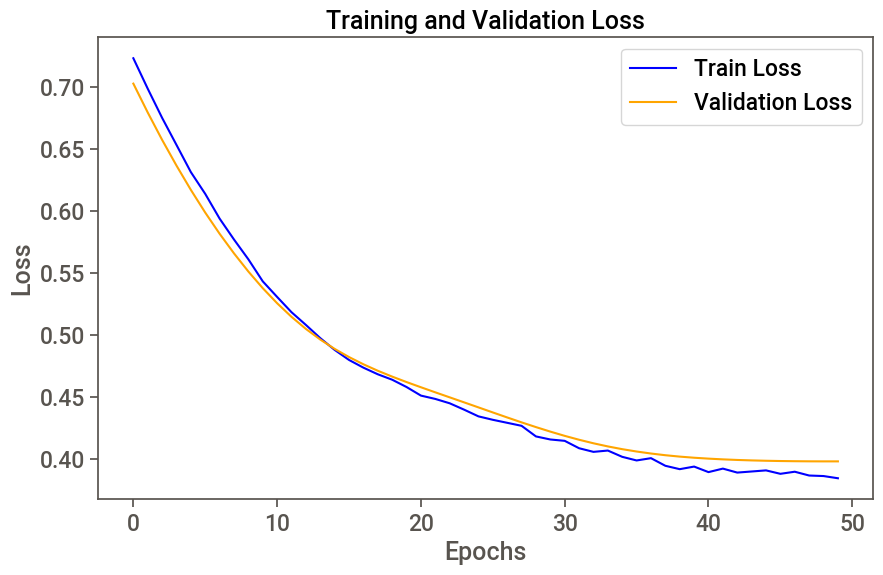

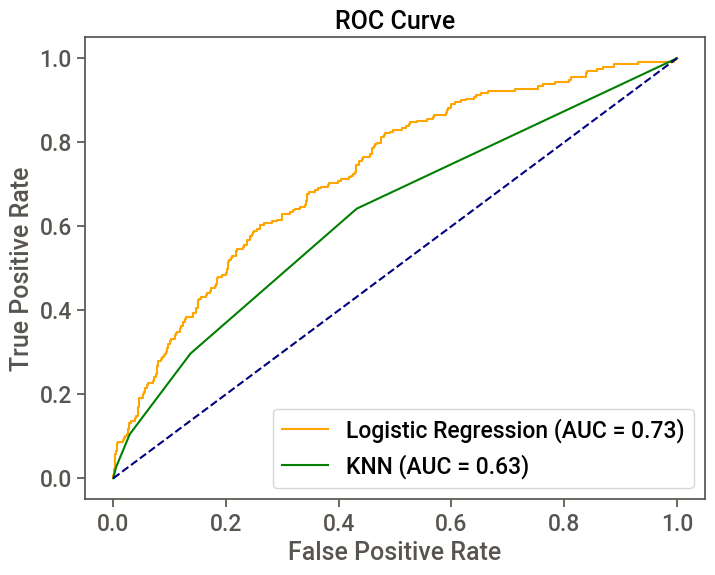

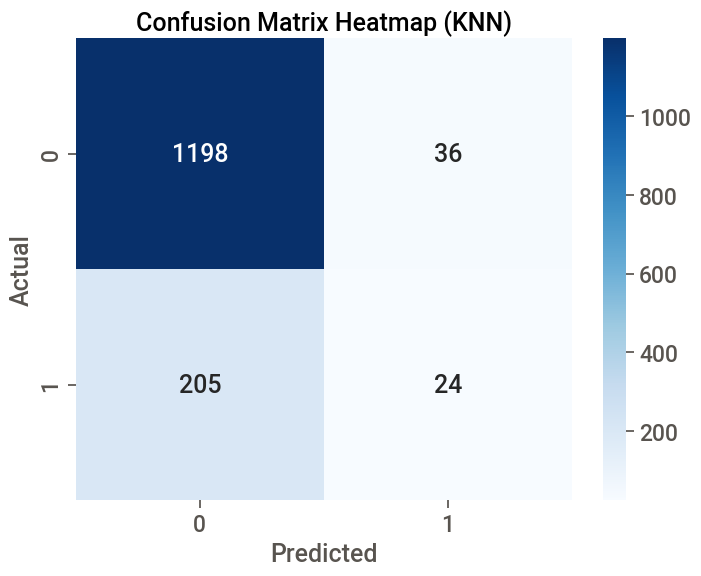

In [25]:


# Define the neural network model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Initialize the model
model = NeuralNetwork(input_size=X_train_scaled.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training and validation loop
train_losses = []
val_losses = []
epochs = 50

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

for epoch in range(epochs):
    # Training
    model.train()
    optimizer.zero_grad()
    train_output = model(X_train_tensor)
    train_loss = criterion(train_output, y_train_tensor)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_test_tensor)
        val_loss = criterion(val_output, y_test_tensor)
        val_losses.append(val_loss.item())

    # Print loss every 10 epochs for monitoring
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# Plot Training and Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label="Train Loss", color="blue")
plt.plot(range(epochs), val_losses, label="Validation Loss", color="orange")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ROC Curve for Logistic Regression and KNN
# Ensure KNN is trained
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_probs_knn = knn.predict_proba(X_test_scaled)[:, 1]

y_probs_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_probs_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probs_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f"Logistic Regression (AUC = {roc_auc_log_reg:.2f})", color="orange")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_knn:.2f})", color="green")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix Heatmap
y_pred_knn = knn.predict(X_test_scaled)
conf_matrix = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap (KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Step 7: Neural Network Model**

Build and train a PyTorch-based neural network for heart disease prediction.


In [26]:
# Define the Neural Network Model
class HeartDiseaseNN(nn.Module):
    def __init__(self, input_size):
        super(HeartDiseaseNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Initialize the model, loss function, and optimizer
input_size = X_train_scaled.shape[1]
model = HeartDiseaseNN(input_size)
# Binary Cross-Entropy Loss
criterion = nn.BCELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
epochs = 50
batch_size = 32
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for i in range(0, len(X_train_tensor), batch_size):
        X_batch = X_train_tensor[i:i+batch_size]
        y_batch = y_train_tensor[i:i+batch_size]
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(X_train_tensor))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss / len(X_train_tensor):.4f}")

# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred_probs = model(X_test_tensor).numpy().ravel()
    y_pred = (y_pred_probs >= 0.5).astype(int)

# Metrics
accuracy_nn = accuracy_score(y_test, y_pred)
conf_matrix_nn = confusion_matrix(y_test, y_pred)
print(f"Neural Network Accuracy: {accuracy_nn:.2f}")
print("Confusion Matrix for Neural Network:\n", conf_matrix_nn)
print("Classification Report for Neural Network:\n", classification_report(y_test, y_pred))


Epoch 1/50, Loss: 0.0148
Epoch 2/50, Loss: 0.0124
Epoch 3/50, Loss: 0.0121
Epoch 4/50, Loss: 0.0119
Epoch 5/50, Loss: 0.0121
Epoch 6/50, Loss: 0.0118
Epoch 7/50, Loss: 0.0118
Epoch 8/50, Loss: 0.0116
Epoch 9/50, Loss: 0.0117
Epoch 10/50, Loss: 0.0117
Epoch 11/50, Loss: 0.0115
Epoch 12/50, Loss: 0.0115
Epoch 13/50, Loss: 0.0117
Epoch 14/50, Loss: 0.0114
Epoch 15/50, Loss: 0.0114
Epoch 16/50, Loss: 0.0114
Epoch 17/50, Loss: 0.0112
Epoch 18/50, Loss: 0.0114
Epoch 19/50, Loss: 0.0111
Epoch 20/50, Loss: 0.0112
Epoch 21/50, Loss: 0.0112
Epoch 22/50, Loss: 0.0112
Epoch 23/50, Loss: 0.0112
Epoch 24/50, Loss: 0.0112
Epoch 25/50, Loss: 0.0112
Epoch 26/50, Loss: 0.0110
Epoch 27/50, Loss: 0.0112
Epoch 28/50, Loss: 0.0111
Epoch 29/50, Loss: 0.0109
Epoch 30/50, Loss: 0.0110
Epoch 31/50, Loss: 0.0109
Epoch 32/50, Loss: 0.0108
Epoch 33/50, Loss: 0.0107
Epoch 34/50, Loss: 0.0108
Epoch 35/50, Loss: 0.0106
Epoch 36/50, Loss: 0.0107
Epoch 37/50, Loss: 0.0108
Epoch 38/50, Loss: 0.0107
Epoch 39/50, Loss: 0.

In [27]:
# Convert X_test to a PyTorch tensor
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Ensure the model is in evaluation mode
model.eval()

# Compute probabilities for test data
# Disable gradient calculations for inference
with torch.no_grad(): 
    # Raw model outputs (logits)
    y_raw_probs_test = model(X_test_tensor)  
     # Convert to probabilities
    y_probs_test = torch.sigmoid(y_raw_probs_test).numpy().flatten() 
print("First 10 predicted probabilities:", y_probs_test[:10])


First 10 predicted probabilities: [0.5077141  0.5015357  0.5327615  0.5048825  0.5544164  0.53188854
 0.5026661  0.5490133  0.5195651  0.5490466 ]


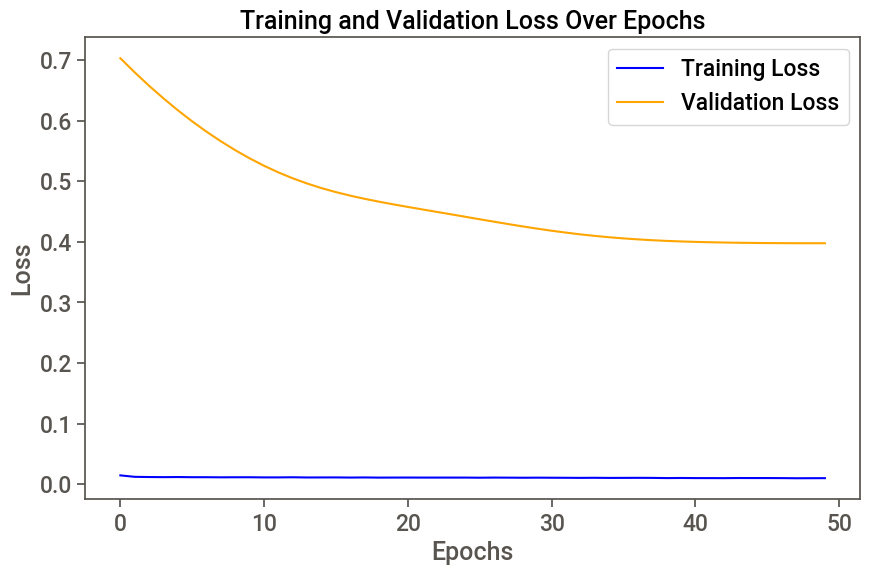

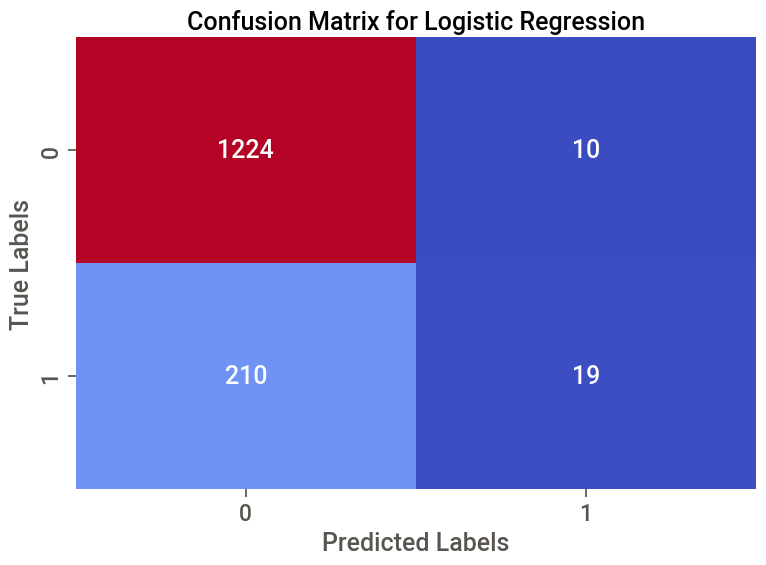

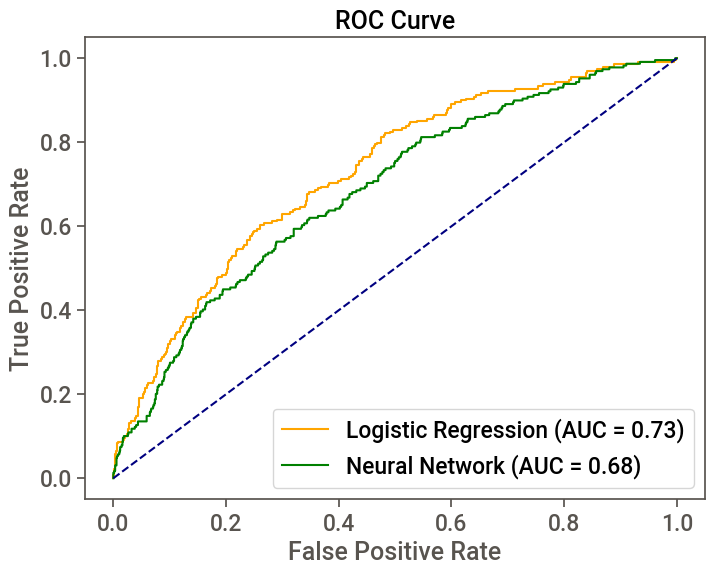

In [28]:
# Visualization: Training and Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Visualization: Confusion Matrix Heatmap

y_pred_log_reg = log_reg.predict(X_test_scaled)
conf_matrix = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', cbar=False)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

# Visualization: ROC Curve
y_probs_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_probs_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

# Compute ROC for Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_probs_test)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f"Logistic Regression (AUC = {roc_auc_log_reg:.2f})", color="orange")
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {roc_auc_nn:.2f})", color="green")
plt.plot([0, 1], [0, 1], linestyle="--", color="navy")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
